# Pretrained atomistic models as featurizers in `mlcolvar`

This tutorial shows how to use a pretrained atomistic model as a frozen feature extractor for learning collective variables (CVs) in `mlcolvar`.

The same workflow is demonstrated for three supported backends:

- **MACE**, using a pretrained MACE-MP model;
- **PET**, using PET-MAD through the metatomic interface;
- **DeePMD-kit**, using a PyTorch DPA-2 model.

Rather than repeating the complete training pipeline three times, the notebook uses a single configuration variable, `BACKBONE_NAME`, to select the desired backend. The remaining steps—dataset construction, element alignment, pooling, CV training, and model export—are shared.

> Run the notebook once for each backend you want to test. Restart the kernel before changing `BACKBONE_NAME`, because different pretrained models may use different numerical precisions.

## 1. Common architecture

All integrations follow the same three-layer design:

```text
external pretrained model
          │
          ▼
model-specific backbone
MACEBackbone / PETBackbone / DeepMDBackbone
          │
          │ atom-level or system-level features
          ▼
AtomisticFeaturizer
          │
          │ freezing, validation, masking, and pooling
          ▼
graph-level representation
          │
          ▼
AtomisticModel
          │
          │ trainable feed-forward readout
          ▼
collective variable
```

The pretrained parameters can remain frozen while gradients with respect to atomic coordinates are preserved. This is essential for using the learned CV in enhanced-sampling simulations.

## 2. Requirements

The core workflow requires `torch`, `lightning`, and `mlcolvar`. Each backend also has an optional dependency:

| Backend | Additional package | Model used here |
|---|---|---|
| MACE | `mace-torch` | MACE-MP small |
| PET | `metatrain`, `metatomic`, `metatensor` | PET-MAD v1.0.2 |
| DeePMD | `deepmd-kit` with PyTorch support | local DPA-2 checkpoint |

The example dataset contains alanine-dipeptide trajectories in two metastable states:

```text
data/alanine_gnn/
├── alad.gro
├── alad_A.trr
└── alad_B.trr
```

Update `DATA_DIR` below if the files are stored elsewhere.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

torch.manual_seed(41)

# Select one of: "mace", "pet", or "deepmd".
BACKBONE_NAME = "mace"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = Path("./data/alanine_gnn")

BATCH_SIZE = 32
MAX_EPOCHS = 1

print("Selected backend:", BACKBONE_NAME)
print("Device:", DEVICE)
print("Dataset directory:", DATA_DIR.resolve())

Selected backend: mace
Device: cuda
Dataset directory: /home/kzhu-iit.local/data/mlcolvar-premodel/docs/notebooks/tutorials/data/alanine_gnn


## 3. Load the pretrained model

The following cell contains only the model-specific part of the workflow. Every branch returns the same two objects:

- `backbone`: a model-specific adapter producing a standardized representation;
- `featurizer`: a generic wrapper that freezes the model and pools atom-level features into graph-level features.

`pooling="mean"` makes the representation less directly dependent on the number of selected atoms. Use `"sum"` when an extensive representation is desired.

In [2]:
from mlcolvar.integrations import AtomisticFeaturizer

BACKBONE_NAME = BACKBONE_NAME.lower()

if BACKBONE_NAME == "mace":
    # MACE-MP models used here operate in float32.
    torch.set_default_dtype(torch.float32)

    from mace.calculators import mace_mp
    from mlcolvar.integrations import MACEBackbone

    calculator = mace_mp(
        model="small",
        device=DEVICE,
        default_dtype="float32",
    )
    pretrained_model = calculator.models[0]
    pretrained_model.eval()

    backbone = MACEBackbone(
        model=pretrained_model,
    )

elif BACKBONE_NAME == "pet":
    # PET-MAD is loaded through the metatrain/metatomic interface.
    torch.set_default_dtype(torch.float64)

    from metatrain.utils.io import load_model
    from mlcolvar.integrations import PETBackbone

    PET_MAD_URL = (
        "https://huggingface.co/lab-cosmo/pet-mad/"
        "resolve/v1.0.2/models/pet-mad-v1.0.2.ckpt"
    )

    pretrained_model = load_model(PET_MAD_URL)
    pretrained_model = pretrained_model.to(
        device=DEVICE,
        dtype=torch.float64,
    )
    pretrained_model.eval()

    backbone = PETBackbone(
        model=pretrained_model,
    )

elif BACKBONE_NAME == "deepmd":
    # The DPA-2 checkpoint must be downloaded separately.
    torch.set_default_dtype(torch.float32)

    from deepmd.pt.model.model.model import BaseModel
    from deepmd.pt.utils.serialization import serialize_from_file
    from mlcolvar.integrations import DeepMDBackbone

    DPA2_MODEL_PATH = Path("./models/DPA-2.4-7M-SPICE2.pth")

    if not DPA2_MODEL_PATH.exists():
        raise FileNotFoundError(
            "DPA-2 checkpoint not found. Update DPA2_MODEL_PATH before "
            "running the DeePMD example."
        )

    serialized_model = serialize_from_file(
        str(DPA2_MODEL_PATH)
    )
    pretrained_model = BaseModel.deserialize(
        serialized_model["model"]
    )
    pretrained_model = pretrained_model.to(
        device=DEVICE,
        dtype=torch.float32,
    )
    pretrained_model.eval()

    backbone = DeepMDBackbone(
        model=pretrained_model,
    )

else:
    raise ValueError(
        "BACKBONE_NAME must be 'mace', 'pet', or 'deepmd', "
        f"found {BACKBONE_NAME!r}."
    )

featurizer = AtomisticFeaturizer(
    backbone=backbone,
    pooling="mean",
    freeze=True,
)

print("Backbone:", type(backbone).__name__)
print("Feature dimension:", backbone.out_features)
print("Sample kind:", backbone.sample_kind)
print(
    "Atomic numbers:",
    backbone.atomic_numbers.detach().cpu().tolist(),
)
print("Cutoff:", float(backbone.cutoff.detach().cpu().item()))
print("Frozen:", featurizer.freeze)

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/si

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using Materials Project MACE for MACECalculator with /home/kzhu-iit.local/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


Backbone: MACEBackbone
Feature dimension: 256
Sample kind: atom
Atomic numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94]
Cutoff: 6.0
Frozen: True


### Backend-specific notes

#### MACE

`MACEBackbone` extracts the pretrained node representation exposed by MACE. The MACE-MP **small** model is used to keep the example relatively lightweight.

#### PET

`PETBackbone` converts the `mlcolvar` graph batch into metatomic systems and extracts PET features. The model may use a different internal precision from the trainable readout; `AtomisticModel` converts the resulting features to the readout precision without disconnecting coordinate gradients.

#### DeePMD

`DeepMDBackbone` uses the descriptor of a serialized DeePMD PyTorch model. The element order is taken from the model type map, and the local checkpoint path must be provided explicitly.

## 4. Construct the graph dataset

The pretrained model determines the neighbor-list cutoff and the required element table. We therefore construct the graph dataset using the standardized cutoff stored by the backbone.

MDTraj stores coordinates in nanometers, whereas the pretrained models in this tutorial expect ångström. Consequently, `lengths_conversion=10.0` is used.

In [3]:
from mlcolvar.io import create_dataset_from_trajectories

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory not found: {DATA_DIR.resolve()}"
    )

load_args = [
    {
        "start": 0,
        "stop": 10000,
        "stride": 5,
    },
    {
        "start": 0,
        "stop": 10000,
        "stride": 5,
    },
]

model_cutoff = float(
    featurizer.cutoff.detach().cpu().item()
)

dataset = create_dataset_from_trajectories(
    trajectories=[
        "alad_A.trr",
        "alad_B.trr",
    ],
    topologies="alad.gro",
    folder=str(DATA_DIR),
    cutoff=model_cutoff,
    system_selection="all",
    show_progress=True,
    load_args=load_args,
    lengths_conversion=10.0,
)

print(dataset)
print("Dataset metadata:", dataset.metadata)

 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 1/4000 Est. 00:6.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 2/4000 Est. 00:5.4
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 3/4000 Est. 00:4.9
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4000 Est. 00:4.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 5/4000 Est. 00:4.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 6/4000 Est. 00:4.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 7/4000 Est. 00:4.5
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 8/4000 Est. 00:4.5
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 9/4000 Est. 00:4.4
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 10/4000 Est. 00:4.5
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 11/4000 Est. 00:4.4
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 12/4000 Est. 00:4.4
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 13/4000 Est. 00:4.4
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 14/4000 Est. 00:4.3
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 15/4000 Est. 00:4.3
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━━ 16/4000 Est. 00:4.3
 

/home/kzhu-iit.local/data/mlcolvar-premodel/mlcolvar/data/graph/utils.py:86: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  graph_labels = torch.tensor( config.graph_labels, dtype=torch.get_default_dtype() )   if config.graph_labels is not None else None


 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 213/4000 Est. 00:3.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 214/4000 Est. 00:3.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 215/4000 Est. 00:3.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 216/4000 Est. 00:3.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 217/4000 Est. 00:3.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 218/4000 Est. 00:3.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 219/4000 Est. 00:3.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 220/4000 Est. 00:3.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 221/4000 Est. 00:3.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 222/4000 Est. 00:3.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 223/4000 Est. 00:3.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 224/4000 Est. 00:3.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 225/4000 Est. 00:3.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 226/4000 Est. 00:3.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 227/4000 Est. 00:3.6
 Making graphs ━━━━━━━━━━━━━━━━━━━━━━━━ 228/4000 Est.

## 5. Align the element encoding

Graph datasets store atomic species in `node_attrs`, typically as one-hot vectors. Their column order must exactly match the element order expected by the pretrained model.

For example, a dataset encoded as `[H, O, C, N]` cannot be passed directly to a model trained with `[H, C, N, O]`, even though both contain the same elements. `align_dataset()` rebuilds the node attributes in the order required by the selected backbone.

In [4]:
print(
    "Dataset atomic numbers before alignment:",
    dataset.metadata["atomic_numbers"],
)

dataset = featurizer.align_dataset(
    dataset
)

example_graph = dataset["data_list"][0]

print(
    "Dataset atomic numbers after alignment:",
    dataset.metadata["atomic_numbers"],
)
print(
    "node_attrs shape:",
    example_graph["node_attrs"].shape,
)
print(
    "Backbone element count:",
    backbone.atomic_numbers.numel(),
)

assert (
    example_graph["node_attrs"].shape[-1]
    == backbone.atomic_numbers.numel()
)
assert (
    len(dataset.metadata["atomic_numbers"])
    == backbone.atomic_numbers.numel()
)

Dataset atomic numbers before alignment: [1, 6, 7, 8]
Dataset atomic numbers after alignment: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94]
node_attrs shape: torch.Size([22, 89])
Backbone element count: 89


## 6. Create the data module

`DictModule` batches the graph dictionaries while preserving the information needed by the atomistic backbone, including atomic positions, graph assignments, cells, neighbor lists, and node attributes.

In [5]:
from mlcolvar.data import DictModule

datamodule = DictModule(
    dataset=dataset,
    batch_size=BATCH_SIZE,
)

print("Datamodule information:")
print(datamodule)

Datamodule information:
DictModule(dataset -> DictDataset( "data_list": 4000,
	    metadata={"atomic_numbers": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94],
		      "cutoff": 6.0,
		      "buffer": 0.0,
		      "long_range_cutoff": -1.0,
		      "system_idx": tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21]),
		      "system_atoms_names": [ACE1-H1, ACE1-CH3, ACE1-H2, ACE1-H3, ACE1-C, ACE1-O, ALA2-N, ALA2-H, ALA2-CA, ALA2-HA, ALA2-CB, ALA2-HB1, ALA2-HB2, ALA2-HB3, ALA2-C, ALA2-O, NME3-N, NME3-H, NME3-C, NME3-H1, NME3-H2, NME3-H3],
		      "is_truncated_graph": False,
		      "data_type": graphs } ),
	     train_loader -> DictLoader(len

## 7. Build a trainable CV readout

`AtomisticModel` combines the frozen featurizer with a trainable feed-forward readout:

```text
atomic graph
    → frozen pretrained representation
    → atom-to-system pooling
    → trainable MLP
    → CV
```

Here the model is used as the neural-network component of `DeepTDA`. The two metastable states are assigned target centers at `-7` and `7`.

In [6]:
from mlcolvar.cvs import DeepTDA
from mlcolvar.integrations import AtomisticModel

atomistic_cv = AtomisticModel(
    featurizer=featurizer,
    n_out=1,
    hidden_layers=(32, 32),
)

model = DeepTDA(
    n_states=2,
    n_cvs=1,
    target_centers=[-7.0, 7.0],
    target_sigmas=[0.2, 0.2],
    model=atomistic_cv,
)

print(model)

DeepTDA(
  (loss_fn): TDALoss()
  (nn): AtomisticModel(
    (featurizer): AtomisticFeaturizer(
      (backbone): MACEBackbone(
        (model): ScaleShiftMACE(
          (node_embedding): LinearNodeEmbeddingBlock(
            (linear): Linear(89x0e -> 128x0e | 11392 weights)
          )
          (radial_embedding): RadialEmbeddingBlock(
            (bessel_fn): BesselBasis(r_max=6.0, num_basis=10, trainable=False)
            (cutoff_fn): PolynomialCutoff(p=5.0, r_max=6.0)
          )
          (spherical_harmonics): SphericalHarmonics()
          (atomic_energies_fn): AtomicEnergiesBlock(energies=[[-3.6672, -1.3321, -3.4821, -4.7367, -7.7249, -8.4056, -7.3601, -7.2846, -4.8965, 0.0000, -2.7594, -2.8140, -4.8469, -7.6948, -6.9633, -4.6726, -2.8117, -0.0626, -2.6176, -5.3905, -7.8858, -10.2684, -8.6651, -9.2331, -8.3050, -7.0490, -5.5774, -5.1727, -3.2521, -1.2902, -3.5271, -4.7085, -3.9765, -3.8862, -2.5185, 6.7669, -2.5635, -4.9380, -10.1498, -11.8469, -12.1389, -8.7917, -8.7869, -7.

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


### Frozen parameters and coordinate gradients

Freezing the backbone sets `requires_grad=False` only for its parameters. It does **not** wrap the forward pass in `torch.no_grad()`. Therefore, derivatives of the CV with respect to atomic coordinates remain available for computing enhanced-sampling forces.

In [7]:
backbone_parameters = list(
    model.nn.featurizer.backbone.parameters()
)
readout_parameters = list(
    model.nn.readout.parameters()
)

print(
    "All backbone parameters frozen:",
    all(
        not parameter.requires_grad
        for parameter in backbone_parameters
    ),
)
print(
    "All readout parameters trainable:",
    all(
        parameter.requires_grad
        for parameter in readout_parameters
    ),
)

n_backbone = sum(
    parameter.numel()
    for parameter in backbone_parameters
)
n_readout = sum(
    parameter.numel()
    for parameter in readout_parameters
)

print("Backbone parameters:", n_backbone)
print("Trainable readout parameters:", n_readout)

All backbone parameters frozen: True
All readout parameters trainable: True
Backbone parameters: 3847696
Trainable readout parameters: 9313


## 8. Train the CV

The number of epochs is intentionally modest for a tutorial. Increase `MAX_EPOCHS` and use proper train/validation settings for production applications.

In [8]:
from lightning import Trainer

from mlcolvar.utils.trainer import MetricsCallback

metrics = MetricsCallback()

trainer = Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    callbacks=[metrics],
    logger=False,
    enable_checkpointing=False,
    max_epochs=MAX_EPOCHS,
    enable_model_summary=False,
)

trainer.fit(
    model,
    datamodule,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:485: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Sanity Checking DataLoader 0:  50%|█████     | 1/2 [00:00<00:00,  2.61it/s]

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 2. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 89 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 49: 100%|██████████| 100/100 [00:07<00:00, 12.90it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 100/100 [00:07<00:00, 12.90it/s]


## 9. Inspect the learning curves

The training and validation losses provide a first diagnostic of optimization. They do not by themselves establish that the learned CV captures the relevant slow process; further validation should include state separation, reweighting, kinetic tests, or enhanced-sampling performance.

{'epoch': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49], 'train_loss': [100.3224868774414, 83.59821319580078, 69.1137466430664, 58.5255241394043, 49.23188781738281, 43.4746208190918, 41.98704528808594, 38.95402526855469, 34.24907684326172, 34.03594970703125, 35.873565673828125, 27.511253356933594, 30.185039520263672, 24.45907974243164, 23.603309631347656, 23.177064895629883, 23.440664291381836, 18.673015594482422, 17.394302368164062, 19.22260284423828, 19.455175399780273, 19.866771697998047, 15.312003135681152, 17.050073623657227, 16.12751579284668, 13.28156852722168, 15.584465026855469, 14.823419570922852, 16.241207122802734, 11.592175483703613, 9.648019790649414, 8.983315467834473, 9.229833602905273, 13.944326400756836, 8.617232322692871, 8.730669975280762, 11.352025032043457, 5.321650981903076, 5.702289581298828, 6.356274604797363, 4.422289

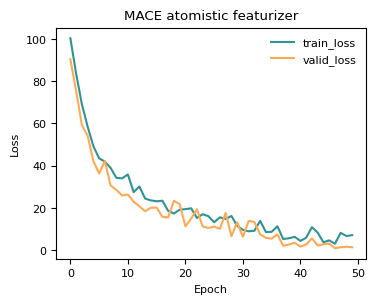

In [9]:
from mlcolvar.utils.plot import plot_metrics

print(metrics.metrics)

fig, ax = plt.subplots(
    1,
    1,
    figsize=(4, 3),
)

plot_metrics(
    metrics.metrics,
    keys=["train_loss", "valid_loss"],
    colors=["fessa1", "fessa5"],
    yscale="linear",
    ax=ax,
)

ax.set_title(
    f"{BACKBONE_NAME.upper()} atomistic featurizer"
)
plt.show()

## 10. Export the inference model

For deployment in an MD or enhanced-sampling workflow, export the inference network rather than the complete Lightning training module.

MACE contains e3nn modules and is scripted with `e3nn.util.jit.script`. PET and DeePMD can use standard `torch.jit.script`.

In [10]:
model.eval()

inference_model = model.nn.eval().cpu()

if BACKBONE_NAME == "mace":
    from e3nn.util import jit as e3nn_jit

    scripted_model = e3nn_jit.script(
        inference_model,
        in_place=False,
    )
else:
    scripted_model = torch.jit.script(
        inference_model
    )

EXPORT_PATH = Path(
    f"deep_tda_{BACKBONE_NAME}_atomistic.pt"
)

torch.jit.save(
    scripted_model,
    str(EXPORT_PATH),
)

print("Saved model to:", EXPORT_PATH.resolve())

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


Saved model to: /home/kzhu-iit.local/data/mlcolvar-premodel/docs/notebooks/tutorials/deep_tda_mace_atomistic.pt


## 11. Check the serialized model

A simple numerical comparison verifies that serialization has not changed the model output. The expected batch key is `data_list`, matching the graph datasets created by `create_dataset_from_trajectories`.

In [11]:
def move_to_device(obj, device):
    """Recursively move tensors in a nested graph batch."""

    if isinstance(obj, torch.Tensor):
        return obj.to(device)

    if isinstance(obj, dict):
        return {
            key: move_to_device(value, device)
            for key, value in obj.items()
        }

    if isinstance(obj, list):
        return [
            move_to_device(value, device)
            for value in obj
        ]

    if isinstance(obj, tuple):
        return tuple(
            move_to_device(value, device)
            for value in obj
        )

    return obj


# Use CPU consistently for TorchScript validation.
validation_device = torch.device("cpu")

# The original inference model may still be on CUDA after training.
inference_model = inference_model.to(
    validation_device
)
inference_model.eval()

# Load the serialized model directly onto CPU.
loaded_model = torch.jit.load(
    str(EXPORT_PATH),
    map_location=validation_device,
)
loaded_model.eval()

# Obtain one validation batch.
datamodule.setup()

batch = next(
    iter(datamodule.val_dataloader())
)

# Move every tensor inside the graph dictionary to CPU.
graph = move_to_device(
    batch["data_list"],
    validation_device,
)

with torch.no_grad():
    reference = inference_model(
        graph
    )

    restored = loaded_model(
        graph
    )

maximum_error = torch.max(
    torch.abs(reference - restored)
).item()

print("Reference device:", reference.device)
print("Restored device:", restored.device)
print("Reference shape:", reference.shape)
print("Restored shape:", restored.shape)
print("Maximum absolute error:", maximum_error)

Reference device: cpu
Restored device: cpu
Reference shape: torch.Size([32, 1])
Restored shape: torch.Size([32, 1])
Maximum absolute error: 0.0


## 12. Summary

The three integrations differ only in how the pretrained model is loaded and how its native representation is extracted. The downstream `mlcolvar` workflow is shared.

| Property | MACE | PET | DeePMD |
|---|---|---|---|
| Adapter | `MACEBackbone` | `PETBackbone` | `DeepMDBackbone` |
| Example model | MACE-MP small | PET-MAD | DPA-2 |
| Model source | automatic download | URL through `metatrain` | local checkpoint |
| Common wrapper | `AtomisticFeaturizer` | `AtomisticFeaturizer` | `AtomisticFeaturizer` |
| Common CV head | `AtomisticModel` | `AtomisticModel` | `AtomisticModel` |
| Coordinate gradients | preserved | preserved | preserved |
| Frozen-model mode | supported | supported | supported |

The reusable pattern is:

```python
backbone = ModelSpecificBackbone(model=pretrained_model)

featurizer = AtomisticFeaturizer(
    backbone=backbone,
    pooling="mean",
    freeze=True,
)

graph_model = AtomisticModel(
    featurizer=featurizer,
    n_out=1,
    hidden_layers=(32, 32),
)
```

This separation keeps optional external dependencies outside the core CV implementation while providing a consistent interface for transfer learning with pretrained atomistic representations.